In [ ]:
%load_ext autoreload
%autoreload 2

import sys
import warnings 
from pathlib import Path
from typing import Optional
from collections import defaultdict
from functools import partial

from tqdm import tqdm

import jax
import jax.numpy as jnp
from jax import jit, grad
jax.config.update("jax_enable_x64", True)

import numpy as np 
import pandas as pd

import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

sys.path.append('./')

from source.models.LaplaceCPR import LaplaceCPR
from source.features import PPNFeature, prepare_fmap
from source.data_functions import load_transform_data
from source.evaluation import rmse, nll, l2_gb_loss, norm_frob
from source.optimization import full_grid
from source.model_functionality import check_zero_cols, predict_score
from source.general_functions import update_results_dict, create_dir_if_not_exists, query_df
from source.matrix_operations import ten3tovec, khatri_rao_row
from source.prob_functions import predict_std, w_sample
from source.visuals import (
    PARAMS, 
    plot_y_list, 
    plot_prediction, 
    plot_dual_axis,
    generate_prediction_gif,
    plot_mtx_list, 
    plot_mtx,
)

warnings.filterwarnings("ignore")
sns.set_theme()

DATA_DIR = Path('./data')

grad_w = jit(grad(l2_gb_loss, argnums=0), static_argnums=(4, 7))

### Q1. Is it useful to use full/block covariance matrix instead of a diagonal one? (23.05.2025)

- CPR-LA vs CPR-LLA?

In [2]:
def compute_stats_cpr(data, model, tracker):
    x, x_test, y, y_test = data
    ys_train, _ = model.predict(x, return_std=True)
    ys_test, ys_std_test = model.predict(x_test, return_std=True)
    
    w_hess_evals = np.linalg.eigvals(model.w_hess).real
    
    v_check = (0, int(model.n_epoch // 2), model.n_epoch-1)
    gd_down = [v for i, v in enumerate(tracker.res_dict['grad_norm']) if i in v_check]
    loss_down = [v for i, v in enumerate(tracker.res_dict['loss']) if i in v_check]
    
    res_dict = dict(
        rmse_train=rmse(y, ys_train), rmse_test=rmse(y_test, ys_test), 
        nll_test=nll(ys_test, ys_std_test**2, y_test), loss=tracker.res_dict['loss'][-1], 
        w_norm = norm_frob(model.w_ten).item(), gd_norm=tracker.res_dict['grad_norm'][-1],
        w_new_rank=(~check_zero_cols(model.w_ten).all(axis=0)).sum().item(),
        max_ev=max(w_hess_evals), min_ev=min(w_hess_evals), 
        w_chol_shape=f"{model.w_cholesky.shape}", 
        loss_down=loss_down == sorted(loss_down, reverse=True),
        gd_down=gd_down == sorted(gd_down, reverse=True),
    )
    return res_dict

In [3]:
class Tracker:
    def __init__(self, x_train, y_train, beta_e, gamma_w, loss, grad_w):
        self.res_dict = defaultdict(list)
        self.x_train = x_train
        self.y_train = y_train
        self.beta_e = beta_e
        self.gamma_w = gamma_w
        self.loss = loss
        self.grad_w = grad_w

    def track(self, w_ten, kd, fmap):
        w_vec, w_shape = ten3tovec(w_ten), w_ten.shape
        train_loss = self.loss(
            w_vec, kd, self.x_train, self.y_train, 
            fmap, self.gamma_w, self.beta_e, w_shape
        ).item()
        grad_norm = norm_frob(
            self.grad_w(
                w_vec, kd, self.x_train, self.y_train, 
                fmap, self.gamma_w, self.beta_e, w_shape
            )
        ).item()

        update_results_dict(self.res_dict, 
            loss=train_loss,
            grad_norm=grad_norm,
        )

#### 1. Training stage:

In [ ]:
DATA_NAME = 'yacht' # yacht, energy, concrete, wine_red
MODEL_NAME = 'cpr_la' # cpr_la, cpr_lla
TRAIN = False

# DO NOT CHANGE:
TEST_SIZE, SPLIT_SEED = 0.1, 1
TRANSFORM_X, TRANSFORM_Y, SCALER = True, True, 'std'
RES_DIR = Path(f'./artifacts/cov_comparison/{MODEL_NAME}/{DATA_NAME}/training_artifacts/')
SAVE_DIR = Path(f'./artifacts/cov_comparison/{MODEL_NAME}/{DATA_NAME}/results/')
create_dir_if_not_exists(RES_DIR)
create_dir_if_not_exists(SAVE_DIR)
nll_res_name, map_res_name = 'nll_info', 'map_tracker'
# Prepare the data:
x, x_test, y, y_test = load_transform_data(
    DATA_DIR / f'{DATA_NAME}.csv', TEST_SIZE, SPLIT_SEED, TRANSFORM_X, TRANSFORM_Y, SCALER)
x, x_test, y, y_test = map(jnp.array, [x, x_test, y, y_test])
params = dict(m_order=[8,], rank=[10,], fmap=[PPNFeature(),], gamma_w=[1e-6,], 
    beta_e=[1.0,], n_epoch=[100,], pd_mode=[MODEL_NAME.split('_')[1],], seed=[13,],
    hess_type=['full', 'gauss_newton', 'block', 'mf', 'last'],
    hess_th=[1e-5, 1e-3, 1e-2, 1e-1, 1e0, 1e1, 1e2], pd_sample_seed=[1,]
)
grid, param_names = full_grid(params)
if TRAIN:
    res_dict = defaultdict(list)
    for v in tqdm(grid):
        conf = dict(zip(param_names, v))
        tracker = Tracker(x, y, conf['beta_e'], conf['gamma_w'], l2_gb_loss, grad_w)
        laplace_cpr = LaplaceCPR(tracker=tracker, **conf)
        laplace_cpr.fit(x, y)
        stats = compute_stats_cpr([x, x_test, y, y_test], laplace_cpr, tracker)
        update_results_dict(res_dict, **stats, **conf, **dict(N=x.shape[0], D=x.shape[1]))
    pd.DataFrame(tracker.res_dict).to_csv(RES_DIR / f'{map_res_name}.csv')
    pd.DataFrame(res_dict).to_csv(RES_DIR / f'{nll_res_name}.csv')
    
map_df = pd.read_csv(RES_DIR / f'{map_res_name}.csv', index_col=0)
res_df = pd.read_csv(RES_DIR / f'{nll_res_name}.csv', index_col=0)

100%|██████████| 35/35 [04:05<00:00,  7.02s/it]


#### 2. Postprocessing stage:

##### Q1. Is LLA better than LA for CPD-based regression?

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
from typing import Optional

def plot_multiple_y_lists_subplots(
    multi_y_lists,              # List of y_lists
    x=None,                     # Shared or per-subplot x
    leg_lists=None,            # List of legends per subplot
    titles=None,               # Titles for each subplot
    xlabel='T',
    ylabel='NLL',
    x_scale='linear',
    y_scale='linear',
    save_path: Optional[str] = None,
    show_plot: bool = True,
    dpi: int = 200,
    figsize: tuple[int] = (12, 6),
    ncols: int = 2,
):
    num_subplots = len(multi_y_lists)
    nrows = (num_subplots + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize, squeeze=False)
    axes = axes.flatten()

    for i, y_list in enumerate(multi_y_lists):
        ax = axes[i]

        # Handle x per subplot or shared
        if x is None:
            x_vals = [np.arange(len(y)) for y in y_list]
        elif isinstance(x[0], (int, float)):  # one shared x for all
            x_vals = [x] * len(y_list)
        else:
            x_vals = x[i]  # per subplot x[i] is a list of x's per curve

        # Plot each line in subplot
        for j, y in enumerate(y_list):
            ax.plot(x_vals[j], y, marker='*', linestyle='-',
                    label='' if leg_lists is None else leg_lists[i][j])

        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.set_xscale(x_scale)
        ax.set_yscale(y_scale)

        if titles and i < len(titles):
            ax.set_title(titles[i])
        if leg_lists:
            ax.legend()

    # Hide unused axes
    for j in range(num_subplots, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=dpi, bbox_inches="tight")
    if show_plot:
        plt.show()
    else:
        plt.close()


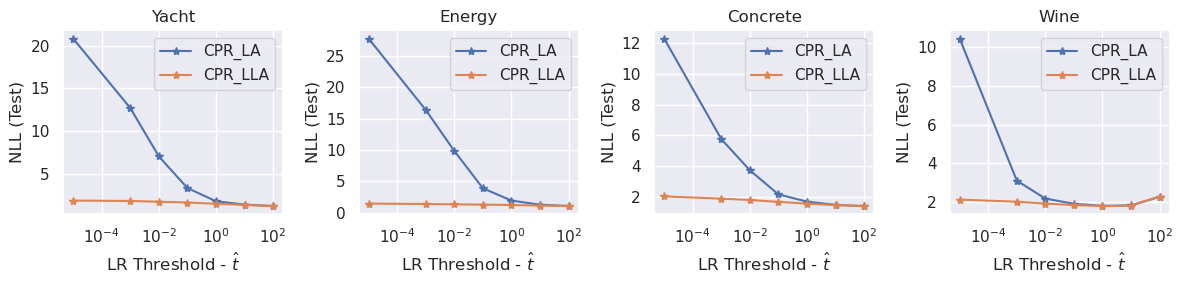

In [9]:
SAVE_DIR = Path(f'./artifacts/cov_comparison/Q1_LLAvsLA/results/')
create_dir_if_not_exists(SAVE_DIR)

hess_type = 'full'
data_name_list = ['yacht', 'energy', 'concrete', 'wine_red']
multi_y_lists, leg_lists, titles = [], [], []
for data_name in data_name_list:
    hess_type = 'full'

    x_name, y_name = 'hess_th', 'nll_test'
    y_list, leg_list = [], []
    model_name_list = ['cpr_la', 'cpr_lla']
    for model_name in model_name_list:
        res_dir = Path(f'./artifacts/cov_comparison/{model_name}/{data_name}/training_artifacts/')
        res_df = pd.read_csv(res_dir / 'nll_info.csv', index_col=0)
        tdf = query_df(res_df, dict(hess_type=hess_type)).sort_values(by=x_name)
        y_list.append(tdf[y_name].to_list())
        leg_list.append(model_name.upper())
        x_range = tdf[x_name].to_list()
    multi_y_lists.append(y_list)
    leg_lists.append(leg_list)
    titles.append(data_name.split('_')[0].capitalize())

plot_multiple_y_lists_subplots(
    multi_y_lists=multi_y_lists,
    x=x_range,
    leg_lists=leg_lists,
    titles=titles,
    xlabel=r'LR Threshold - $\hat{t}$',
    ylabel='NLL (Test)',
    ncols=4,
    x_scale='log', 
    y_scale='linear',
    figsize=(12, 3),
    save_path=SAVE_DIR / f'linearization.png',
    dpi=500,
)

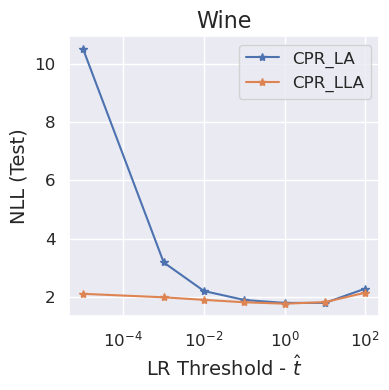

In [80]:
DATA_NAME = 'wine_red' # yacht, energy, concrete, wine_red
hess_type = 'full'
SAVE_DIR = Path(f'./artifacts/cov_comparison/Q1_LLAvsLA/{DATA_NAME}/results/')
create_dir_if_not_exists(SAVE_DIR)

x_name, y_name = 'low_rank_th', 'nll_test'
y_list, leg_list = [], []
model_name_list = ['cpr_la', 'cpr_lla']
for model_name in model_name_list:
    res_dir = Path(f'./artifacts/cov_comparison/{model_name}/{DATA_NAME}/training_artifacts/')
    res_df = pd.read_csv(res_dir / 'nll_info.csv', index_col=0)
    tdf = query_df(res_df, dict(hess_type=hess_type)).sort_values(by=x_name)
    y_list.append(tdf[y_name])
    leg_list.append(model_name.upper())
    x_range = tdf[x_name]


title = f'{DATA_NAME.split('_')[0].capitalize()}'
plot_y_list(
    y_list, x_range, leg_list, 
    xlabel=r'LR Threshold - $\hat{t}$', 
    ylabel='NLL (Test)', 
    x_scale='log', 
    y_scale='linear',
    figsize=(4, 4),
    text=None,
    title=title,#f'Does Linearization Help? ({DATA_NAME.capitalize()} Data)',
    save_path=SAVE_DIR / f'{DATA_NAME}_linearization.png'
)

##### Q2. What is the trade-off between different covariance matrix estimators: Full, GGN, Block, Diagonal, Last?

In [10]:
import matplotlib.pyplot as plt
import numpy as np
from typing import Optional

def plot_multiple_y_lists_subplots(
    multi_y_lists,              # List of y_lists
    x=None,                     # Shared or per-subplot x
    leg_labels=None,            # One list of labels shared across all subplots
    titles=None,                # Titles for each subplot
    xlabel='T',
    ylabel='NLL',
    x_scale='linear',
    y_scale='linear',
    save_path: Optional[str] = None,
    show_plot: bool = True,
    dpi: int = 200,
    figsize: tuple[int] = (12, 6),
    ncols: int = 2,
):
    num_subplots = len(multi_y_lists)
    nrows = (num_subplots + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize, squeeze=False)
    axes = axes.flatten()

    # Store one set of handles/labels for the shared legend
    shared_handles = []

    for i, y_list in enumerate(multi_y_lists):
        ax = axes[i]

        # Handle x per subplot or shared
        if x is None:
            x_vals = [np.arange(len(y)) for y in y_list]
        elif isinstance(x[0], (int, float)):  # one shared x for all
            x_vals = [x] * len(y_list)
        else:
            x_vals = x[i]  # per subplot x[i] is a list of x's per curve

        # Plot each line in subplot
        for j, y in enumerate(y_list):
            label = leg_labels[j] if leg_labels else f'Line {j+1}'
            line, = ax.plot(x_vals[j], y, marker='*', linestyle='-', label=label)
            if i == 0:  # Collect legend handles only once
                shared_handles.append(line)

        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.set_xscale(x_scale)
        ax.set_yscale(y_scale)

        if titles and i < len(titles):
            ax.set_title(titles[i])

    # Hide unused axes
    for j in range(num_subplots, len(axes)):
        fig.delaxes(axes[j])

    # Add shared legend at bottom
    legend = fig.legend(
        handles=shared_handles,
        labels=leg_labels if leg_labels else [f'Line {i+1}' for i in range(len(shared_handles))],
        loc='lower center',
        bbox_to_anchor=(0.5, -0.05),
        ncol=len(shared_handles),
        frameon=True
    )
    legend.get_frame().set_edgecolor('black')
    legend.get_frame().set_linewidth(1.0)

    plt.tight_layout(rect=[0, 0.05, 1, 1])  # leave space at bottom for legend

    if save_path:
        plt.savefig(save_path, dpi=dpi, bbox_inches="tight")
    if show_plot:
        plt.show()
    else:
        plt.close()


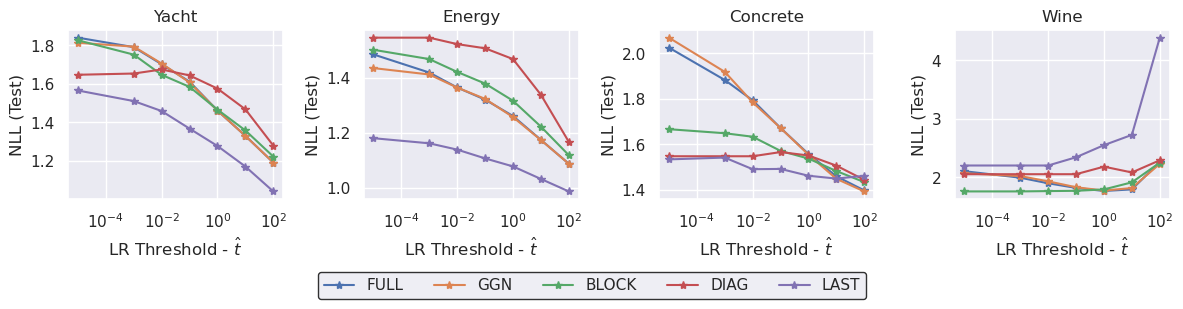

In [11]:
SAVE_DIR = Path(f'./artifacts/cov_comparison/Q2_HessMode/results/')
create_dir_if_not_exists(SAVE_DIR)

model_name = 'cpr_lla'
data_name_list = ['yacht', 'energy', 'concrete', 'wine_red']
multi_y_lists, leg_lists, titles = [], [], []
for data_name in data_name_list:
    res_dir = Path(f'./artifacts/cov_comparison/{model_name}/{data_name}/training_artifacts/')
    res_df = pd.read_csv(res_dir / 'nll_info.csv', index_col=0)

    x_name, y_name = 'hess_th', 'nll_test'
    y_list, leg_list = [], []
    for hess_type in ['full', 'gauss_newton', 'block', 'mf', 'last']:
        tdf = query_df(res_df, dict(hess_type=hess_type)).sort_values(by=x_name)
        y_list.append(tdf[y_name].to_list())

        if hess_type == 'gauss_newton':
            leg_list.append('GGN')
        elif hess_type == 'mf':
            leg_list.append('DIAG')
        else:
            leg_list.append(hess_type.upper())
        x_range = tdf[x_name].to_list()
    multi_y_lists.append(y_list)
    leg_lists.append(leg_list)
    titles.append(data_name.split('_')[0].capitalize())

plot_multiple_y_lists_subplots(
    multi_y_lists=multi_y_lists,
    x=x_range,
    leg_labels=leg_lists[0],
    titles=titles,
    xlabel=r'LR Threshold - $\hat{t}$',
    ylabel='NLL (Test)',
    x_scale='log',
    y_scale='linear',
    figsize=(12, 3),
    ncols=4,
    save_path=SAVE_DIR / f'hess_mode.png',
    dpi=500,
)

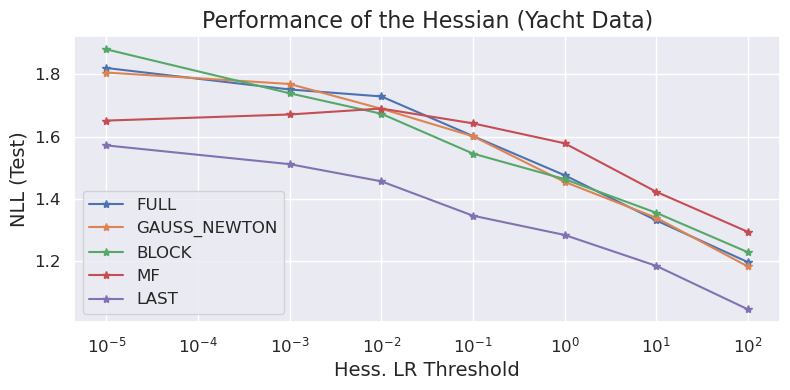

In [30]:
x_name, y_name = 'low_rank_th', 'nll_test'
y_list, leg_list = [], []
for hess_type in ['full', 'gauss_newton', 'block', 'mf', 'last']:
    tdf = query_df(res_df, dict(hess_type=hess_type)).sort_values(by=x_name)
    y_list.append(tdf[y_name])
    leg_list.append(hess_type.upper())
    x_range = tdf[x_name]

plot_y_list(
    y_list, x_range, leg_list, 
    xlabel='Hess. LR Threshold', 
    ylabel='NLL (Test)', 
    x_scale='log', 
    text=None,
    title=f'Performance of the Hessian ({DATA_NAME.capitalize()} Data)',
    save_path=SAVE_DIR / f'{DATA_NAME}_hess_perf.png'
)

##### TODO?

##### Hessian Estimators:

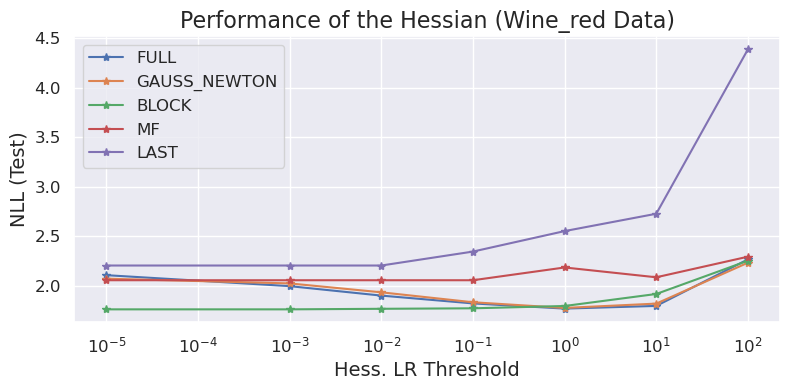

In [5]:
x_name, y_name = 'hess_th', 'nll_test'
y_list, leg_list = [], []
for hess_type in ['full', 'gauss_newton', 'block', 'mf', 'last']:#params['hess_type']:
    tdf = query_df(res_df, dict(hess_type=hess_type)).sort_values(by=x_name)
    y_list.append(tdf[y_name])
    leg_list.append(hess_type.upper())
    x_range = tdf[x_name]

plot_y_list(
    y_list, x_range, leg_list, 
    xlabel='Hess. LR Threshold', 
    ylabel='NLL (Test)', 
    x_scale='log', 
    text=None,
    title=f'Performance of the Hessian ({DATA_NAME.capitalize()} Data)',
    save_path=SAVE_DIR / f'{DATA_NAME}_hess_perf.png'
)

##### Predictive Distribution PNG:

In [52]:
hess_type = 'block'

changed_cols = ['hess_type', 'low_rank', 'low_rank_th']
p_fixed = {k:v[0] for k, v in params.items() if k not in changed_cols}
best_setting = dict(query_df(res_df, dict(hess_type=hess_type)).sort_values(by='nll_test', ascending=True).iloc[0])
conf = p_fixed | {k:v for k, v in best_setting.items() if k in changed_cols}
conf['low_rank_th'] = 1e2
fmap, w_ten, kd, w_hess, w_cov, w_cholesky, tracker = train_cpr(
    x, y, grad_w, OPT, conf
)

In [53]:
conf, p_fixed['beta_e']

({'m_order': 8,
  'rank': 10,
  'fmap': PPNFeature(name='ppnf'),
  'gamma_w': 1e-06,
  'beta_e': 1.0,
  'n_epoch': 100,
  'seed': 13,
  'low_rank': True,
  'hess_type': 'block',
  'low_rank_th': 100.0},
 1.0)

1.1068842175674034


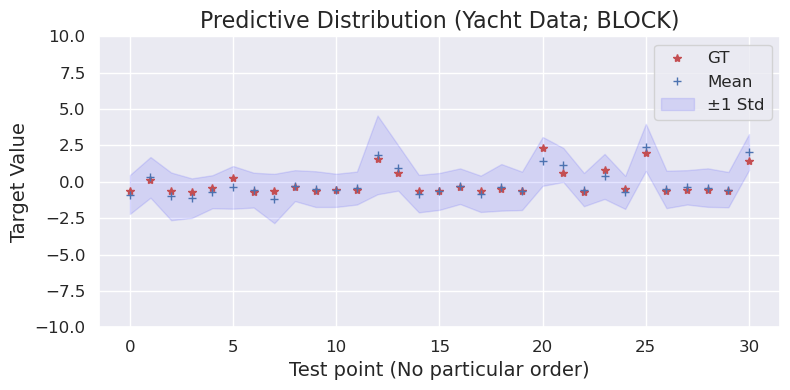

In [54]:
ys_test = predict_score(x_test, kd, w_ten, fmap)
ys_std_test = predict_std(w_ten, w_cholesky, kd, x_test, fmap, beta_e=1, n_samples=50) 

print(nll(ys_test, ys_std_test, y_test))

plot_prediction(
    y_test, ys_test, ys_std_test, 
    xlabel='Test point (No particular order)',
    ylabel='Target Value',
    title=f'Predictive Distribution ({DATA_NAME.capitalize()} Data; {hess_type.upper()})',
    save_path=SAVE_DIR / f'{DATA_NAME}_pred_dist.png',
    ylim=(-10, 10)
)

##### Predictive Distribution GIF:

In [ ]:
hess_type = 'block'
changed_cols = ['hess_type', 'low_rank', 'low_rank_th']
p_fixed = {k:v[0] for k, v in params.items() if k not in changed_cols}

means_list = []
stds_list = []
for th in tqdm(params['low_rank_th']):
    conf = p_fixed | dict(hess_type=hess_type, low_rank=True, low_rank_th=th)
    fmap, w_ten, kd, w_hess, w_cov, w_cholesky, tracker = train_cpr(
        x, y, grad_w, OPT, conf
    )
    mean = predict_score(x_test, kd, w_ten, fmap)
    std = predict_std(w_ten, w_cholesky, kd, x_test, fmap, 1, n_samples=50)
    means_list.append(mean)
    stds_list.append(std)
    
generate_prediction_gif(
    x_vals=params['low_rank_th'],
    y_gt=y_test,
    means_list=means_list,
    stds_list=stds_list,
    save_gif_path=SAVE_DIR / f'{DATA_NAME}_pred_dist.gif',
    xlabel=f'Test point ({DATA_NAME.capitalize()} Data)',
    ylabel='Target value',
    title_prefix=f'Predictive Distribution. {hess_type.upper()}, ',
    duration=1000,  # seconds per frame
    ylim=(-6, 6) 
)

##### Eigenvalues of the Hessian:

In [ ]:
x_name, y_name = 'low_rank_th', 'w_chol_shape'
y_list, leg_list, text_list = [], [], []
for hess_type in params['hess_type']:
    tdf = query_df(res_df, dict(hess_type=hess_type)).sort_values(by=x_name)
    y_list.append([int(v.strip('()').split(',')[1]) for v in tdf[y_name]])
    leg_list.append(hess_type.upper())
    x_range = tdf[x_name]

plot_y_list(
    y_list, x_range, leg_list, 
    xlabel='Hess. LR Threshold', 
    ylabel='#Non-Zero Eigenvalues', 
    title=f'Eigenvalues of the Hessian ({DATA_NAME.capitalize()} Data)', 
    x_scale='log',
    save_path=None
)

### Test NLL Real Data (14.04.2025) - OUTDATED:

- Compare Low-rank Full(GN), Block Diagonal, MeanField covariance matrix
- Use RMSE and NLL on train and test to check the performance
- Should we use Full Covariance?
- Check 1HNN, Non-Tensorized model, GP(RBF), CPD-LA Model, CPD-LLA Model.

#### Non-Tensorized Model:

In [59]:
from source.var_model import cov_estimation, low_rank_cov_estimation

def ls_sol(x, y, fmap, gamma_w, beta_e):
    F_mtx = get_design_mtx(x, fmap)
    A_mtx = beta_e*F_mtx.T.conj().dot(F_mtx) + gamma_w*jnp.eye(F_mtx.shape[1])
    b = beta_e*F_mtx.T.conj().dot(y)
    return A_mtx, jnp.linalg.solve(A_mtx, b)

def train_model_pure(x, y, grad_w, conf):
    fmap, _ = prepare_fmap(conf['fmap'], conf['m_order'], is_quant=False)
    w_hess, w_vec = ls_sol(x, y, fmap, conf['gamma_w'], conf['beta_e'])
    tracker = defaultdict(list)
    update_results_dict(
        tracker, loss=l2_reg_loss(w_vec, x, y, fmap, conf['gamma_w'], conf['beta_e']).item(),
        grad_norm=norm_frob(grad_w(w_vec, x, y, fmap, conf['gamma_w'], conf['beta_e'])).item(),
    )
    if conf['hess_type'] == 'full': w_hess = w_hess
    elif conf['hess_type'] == 'mf': w_hess = jnp.diag(jnp.diagonal(w_hess))
    else: assert False

    if conf['low_rank']: cov_f = partial(low_rank_cov_estimation, threshold=conf['low_rank_th'])
    else: cov_f = cov_estimation
    
    try: w_cov, w_cholesky = cov_f(w_hess); 
    except Exception as e: w_cov, w_cholesky = None, None

    return fmap, w_vec, w_hess, w_cov, w_cholesky, tracker

def predict_score(w_vec, x, fmap):
    return jnp.real(get_design_mtx(x, fmap).dot(w_vec))

def l2_reg_loss(w_vec, x, y, fmap, gamma_w, beta_e):
    scores = predict_score(w_vec, x, fmap)
    return 0.5*(beta_e*jnp.sum((y - scores)**2) + gamma_w*(w_vec * w_vec).sum())

def get_design_mtx(x, fmap):
    design_mtx = fmap(x[:, 0], None)
    for k in range(1, x.shape[1]):
        design_mtx = khatri_rao_row(fmap(x[:, k], None), design_mtx)
    return design_mtx

def predict_std_pure(w_vec, w_cholesky, x, fmap, beta_e, n_samples=10):
    preds = []
    for _ in range(n_samples):
        w_vec_sample = w_sample(w_vec, w_cholesky)
        scores = predict_score(w_vec_sample, x, fmap)
        preds.append(scores[:, None])
    pred_std = jnp.std(jnp.hstack(preds), axis=1)
    std_err = 1 / jnp.sqrt(beta_e)
    return pred_std + std_err

def compute_stats_pure(data, fmap, conf, w_vec, w_hess, w_cholesky, tracker):
    x, x_test, y, y_test = data
    ys_train = predict_score(w_vec, x, fmap)
    ys_test = predict_score(w_vec, x_test, fmap)
    ys_var_test = predict_std_pure(w_vec, w_cholesky, x_test, fmap, conf['beta_e'], n_samples=50)**2
    w_hess_evals = np.linalg.eigvals(w_hess).real
    
    v_check = (0, int(conf['n_epoch'] // 2), conf['n_epoch']-1)
    gd_down = [v for i, v in enumerate(tracker['grad_norm']) if i in v_check]
    loss_down = [v for i, v in enumerate(tracker['loss']) if i in v_check]
    
    res_dict = dict(
        rmse_train=rmse(y, ys_train), rmse_test=rmse(y_test, ys_test), 
        nll_test=nll(ys_test, ys_var_test, y_test), loss=tracker['loss'][-1], 
        w_norm = norm_frob(w_vec).item(), gd_norm=tracker['grad_norm'][-1],
        max_ev=max(w_hess_evals), min_ev=min(w_hess_evals), 
        w_chol_shape=f"{w_cholesky.shape}", 
        loss_down=loss_down == sorted(loss_down, reverse=True),
        gd_down=gd_down == sorted(gd_down, reverse=True),
    )
    return res_dict

grad_w_pure = jit(grad(l2_reg_loss, argnums=0), static_argnums=(3,))

##### Train Pure Model:

In [85]:
DATA_NAME = 'wine_red' # yacht, energy, concrete, wine_red
TEST_SIZE, SPLIT_SEED = 0.1, 1
TRANSFORM_X, TRANSFORM_Y, SCALER = True, True, 'std'
TRAIN = True

# Prepare the data:
x, x_test, y, y_test = load_transform_data(
    DATA_DIR / f'{DATA_NAME}.csv', TEST_SIZE, SPLIT_SEED, TRANSFORM_X, TRANSFORM_Y, SCALER)
x, x_test, y, y_test = map(jnp.array, [x, x_test, y, y_test])
dt = [x, x_test, y, y_test]
n_samples, d_dim = x.shape

RES_DIR = Path(f'./artifacts/cov_comparison/pure_model/{DATA_NAME}/training_artifacts/')
create_dir_if_not_exists(RES_DIR)

params = dict(m_order=[2,], fmap=[PPNFeature(),], gamma_w=[1e-6,], beta_e=[1.0,],
    n_epoch=[1,], seed=[13,], hess_type=['mf', 'full'], low_rank=[True,],
    low_rank_th=[1e-6, 1e-5, 1e-3, 1e-2, 1e-1, 1e0, 1e1, 1e2]
)
grid, param_names = full_grid(params)
if TRAIN:
    res_dict = defaultdict(list)
    for v in tqdm(grid):
        conf = dict(zip(param_names, v))
        fmap, w_vec, w_hess, w_cov, w_cholesky, tracker = train_model_pure(x, y, grad_w_pure, conf)
        stats = compute_stats_pure(dt, fmap, conf, w_vec, w_hess, w_cholesky, tracker)
        update_results_dict(res_dict, **stats, **conf)
    res_df = pd.DataFrame(res_dict)
    res_df.to_csv(RES_DIR / 'nll_info.csv')
else:
    res_df = pd.read_csv(RES_DIR / 'nll_info.csv', index_col=0)

SAVE_DIR = Path(f'./artifacts/cov_comparison/pure_model/{DATA_NAME}/results/')
create_dir_if_not_exists(SAVE_DIR)

100%|██████████| 16/16 [00:47<00:00,  2.98s/it]


PosixPath('artifacts/cov_comparison/pure_model/wine_red/results')

##### Hessian Estimators:

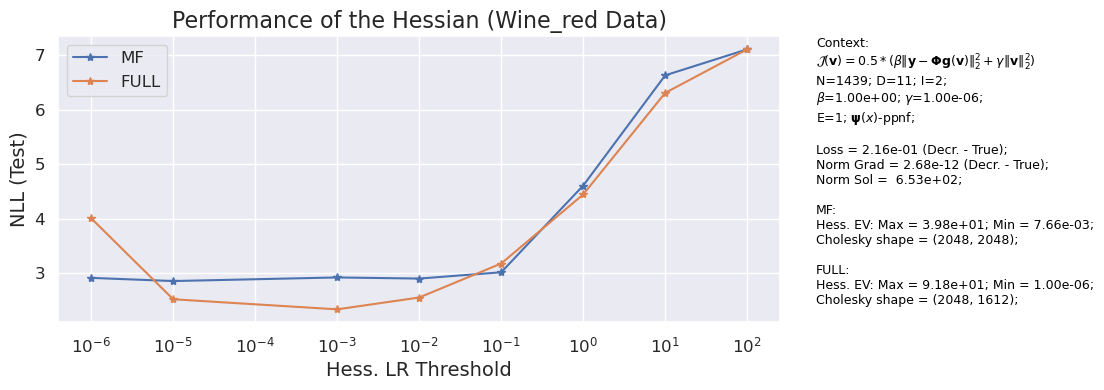

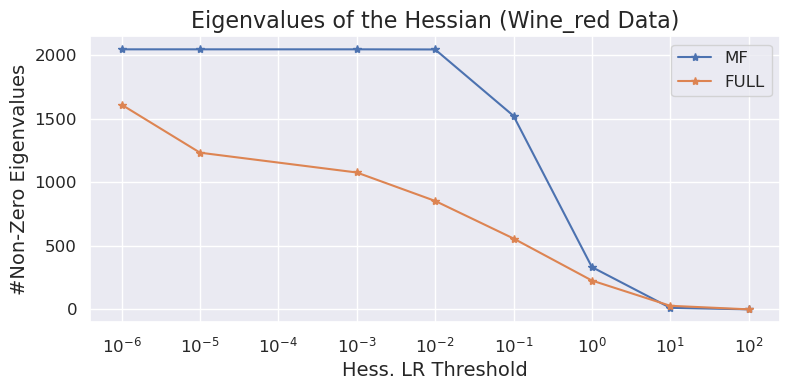

In [86]:
x_name, y_name = 'low_rank_th', 'nll_test'
y_list, leg_list, text_list = [], [], []
for hess_type in params['hess_type']:
    tdf = query_df(res_df, dict(hess_type=hess_type)).sort_values(by=x_name)
    y_list.append(tdf[y_name])
    leg_list.append(hess_type.upper())
    x_range = tdf[x_name]
    text_list.append(
        (
            f'\n{hess_type.upper()}:\n'
            + f'Hess. EV: Max = {tdf["max_ev"].iloc[0]:.2e}; Min = {tdf["min_ev"].iloc[0]:.2e};\n'
            + f'Cholesky shape = {tdf["w_chol_shape"].iloc[0]};\n'
        )
    )

p_fixed = {k:v[0] for k, v in params.items() if k not in ['hess_type', 'low_rank', 'low_rank_th']}
p_fixed['fmap'] = p_fixed['fmap'].name

loss_val, loss_dec = res_df['loss'][0], res_df['loss_down'][0]
gd_norm_val, gd_norm_dec = res_df['gd_norm'][0], res_df['gd_down'][0]
w_norm = res_df['w_norm'][0]

text = get_text(n_samples, d_dim, **p_fixed)
text += (
    f'\nLoss = {loss_val:.2e} (Decr. - {loss_dec});\n'
    + f'Norm Grad = {gd_norm_val:.2e} (Decr. - {gd_norm_dec});\n'
    + f'Norm Sol = {w_norm: .2e};\n'
)
for v in text_list:
    text += v

title = f'Performance of the Hessian ({DATA_NAME.capitalize()} Data)'
save_path = SAVE_DIR / f'{DATA_NAME}_hess_perf.png'

plot_y_list(
    y_list, x_range, leg_list, 
    xlabel='Hess. LR Threshold', 
    ylabel='NLL (Test)', 
    x_scale='log', 
    text=text,
    title=f'Performance of the Hessian ({DATA_NAME.capitalize()} Data)',
    save_path=SAVE_DIR / f'{DATA_NAME}_hess_perf.png'
)

x_name, y_name = 'low_rank_th', 'w_chol_shape'
y_list, leg_list, text_list = [], [], []
for hess_type in params['hess_type']:
    tdf = query_df(res_df, dict(hess_type=hess_type)).sort_values(by=x_name)
    y_list.append([int(v.strip('()').split(',')[1]) for v in tdf[y_name]])
    leg_list.append(hess_type.upper())
    x_range = tdf[x_name]

plot_y_list(
    y_list, x_range, leg_list, 
    xlabel='Hess. LR Threshold', 
    ylabel='#Non-Zero Eigenvalues', 
    x_scale='log',
    title=f'Eigenvalues of the Hessian ({DATA_NAME.capitalize()} Data)',
    save_path=SAVE_DIR / f'{DATA_NAME}_nonzero_ev.png'
)

##### Predictive Distribution:

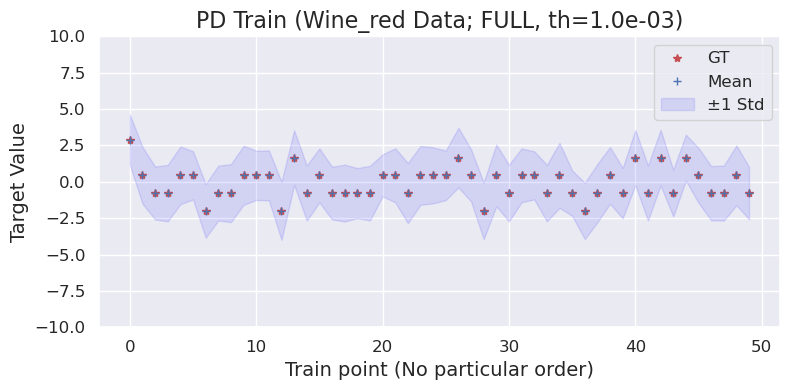

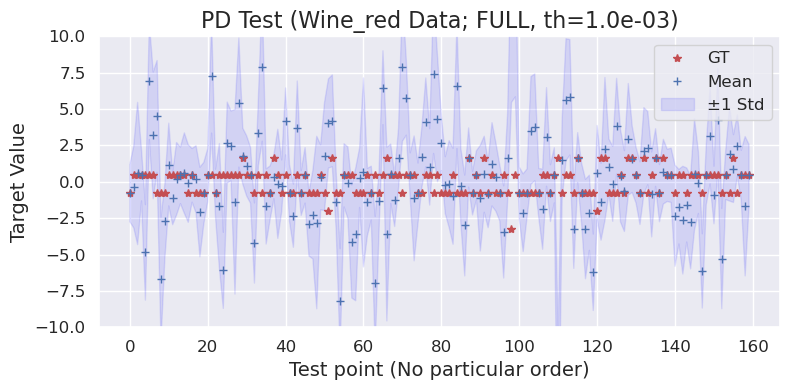

In [87]:
hess_type = 'full'

changed_cols = ['hess_type', 'low_rank', 'low_rank_th']
p_fixed = {k:v[0] for k, v in params.items() if k not in changed_cols}
best_setting = dict(query_df(res_df, dict(hess_type=hess_type)).sort_values(by='nll_test', ascending=True).iloc[0])
conf = p_fixed | {k:v for k, v in best_setting.items() if k in changed_cols}

fmap, w_vec, w_hess, w_cov, w_cholesky, tracker = train_model_pure(x, y, grad_w_pure, conf)

n_train_show = 50
plot_prediction(
    y[:n_train_show], 
    predict_score(w_vec, x[:n_train_show, :], fmap), 
    predict_std_pure(w_vec, w_cholesky, x[:n_train_show, :], fmap, conf['beta_e'], n_samples=50),
    xlabel='Train point (No particular order)',
    ylabel='Target Value',
    title=f'PD Train ({DATA_NAME.capitalize()} Data; {conf["hess_type"].upper()}, th={conf["low_rank_th"]:.1e})',
    save_path=SAVE_DIR / f'{DATA_NAME}_pred_dist_train.png',
    ylim=(-10, 10)
)

plot_prediction(
    y_test, 
    predict_score(w_vec, x_test, fmap), 
    predict_std_pure(w_vec, w_cholesky, x_test, fmap, conf['beta_e'], n_samples=50), 
    xlabel='Test point (No particular order)',
    ylabel='Target Value',
    title=f'PD Test ({DATA_NAME.capitalize()} Data; {hess_type.upper()}, th={conf["low_rank_th"]:.1e})',
    save_path=SAVE_DIR / f'{DATA_NAME}_pred_dist_test.png',
    ylim=(-10, 10)
)

##### PD Gif:

In [88]:
means_list = []
stds_list = []
for th in tqdm(params['low_rank_th']):
    conf = p_fixed | dict(hess_type=hess_type, low_rank=True, low_rank_th=th)
    fmap, w_vec, w_hess, w_cov, w_cholesky, tracker = train_model_pure(x, y, grad_w_pure, conf)
    
    mean = predict_score(w_vec, x_test, fmap)
    std = predict_std_pure(w_vec, w_cholesky, x_test, fmap, conf['beta_e'], n_samples=50)
    means_list.append(mean)
    stds_list.append(std)

generate_prediction_gif(
    x_vals=params['low_rank_th'],
    y_gt=y_test,
    means_list=means_list,
    stds_list=stds_list,
    save_gif_path=SAVE_DIR / f'{DATA_NAME}_pred_dist.gif',
    xlabel=f'Test point ({DATA_NAME.capitalize()} Data)',
    ylabel='Target value',
    title_prefix=f'Predictive Distribution. {hess_type.upper()}, ',
    duration=1000,  # seconds per frame
    ylim=(-6, 6) 
)

100%|██████████| 8/8 [00:19<00:00,  2.40s/it]


##### Covariance Matrix Eigenvalues:

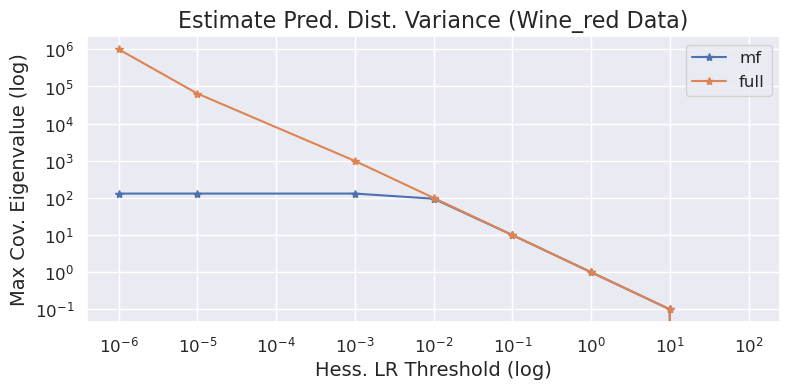

In [89]:
hess_dict, y_list = {}, []
for hess_type in params['hess_type']:
    conf = p_fixed | dict(hess_type=hess_type, low_rank=True, low_rank_th=1e-1)
    fmap, w_vec, w_hess, w_cov, w_cholesky, tracker = train_model_pure(x, y, grad_w_pure, conf)
    hess_dict[hess_type] = np.array(w_hess)
    ys = []
    s, u = np.linalg.eigh(w_hess)
    for th in params['low_rank_th']:
        mask = s >= th
        if sum(mask) > 0:
            ys.append(1/min(s[mask]))
        else:
            ys.append(0)
    y_list.append(ys)

plot_y_list(
    y_list, 
    x=params['low_rank_th'], 
    leg_list=params['hess_type'], 
    xlabel='Hess. LR Threshold (log)', 
    ylabel='Max Cov. Eigenvalue (log)',
    x_scale='log',
    y_scale='log',
    title=f'Estimate Pred. Dist. Variance ({DATA_NAME.capitalize()} Data)',
    save_path=SAVE_DIR / f'{DATA_NAME}_cov_max_ev_th.png'
)

#### Simple NN:

In [ ]:
from jax import random
from jax.flatten_util import ravel_pytree

from source.nn import (
    norm_nn,
    n_params,
    forward_nn,
    init_params,
    train_map_nn, 
    hess_cov_estimation_nn,
)

def train_model_nn(x, y, conf):
    key = random.PRNGKey(conf['seed'])
    nn_w = init_params(key, input_dim=x.shape[1], hidden_dim=conf['hidden_dim'], output_dim=1)
    nn_w_trained, tracker = train_map_nn(nn_w, x, y, conf['beta_e'], conf['gamma_w'], 
        conf['use_linesearch'], conf['opt_method'], conf['lr'], conf['n_epoch'])
    # Hessian/Covariance/Cholesky Evaluation:
    w_hess, w_cov, w_cholesky = hess_cov_estimation_nn(
        nn_w_trained, x, y, conf['gamma_w'], 
        conf['beta_e'], conf['hess_type'], conf['low_rank'], conf['low_rank_th']
    )
    return nn_w_trained, w_hess, w_cov, w_cholesky, tracker

def predict_std_nn(nn_w, w_cholesky, x, beta_e, n_samples=10):
    nn_w_vec, unflatten_fn = ravel_pytree(nn_w)
    preds = []
    for _ in range(n_samples):
        nn_w_vec_sample = w_sample(nn_w_vec, w_cholesky)
        nn_w_sample = unflatten_fn(nn_w_vec_sample)
        scores = forward_nn(nn_w_sample, x)
        preds.append(scores[:, None])
    pred_std = jnp.std(jnp.hstack(preds), axis=1)
    std_err = 1 / jnp.sqrt(beta_e)
    return pred_std + std_err

def compute_stats_nn(data, conf, nn_w, w_hess, w_cholesky, tracker):
    x, x_test, y, y_test = data
    ys_train = forward_nn(nn_w, x)
    ys_test = forward_nn(nn_w, x_test)
    ys_var_test = predict_std_nn(nn_w, w_cholesky, x_test, conf['beta_e'], n_samples=50)**2
    w_hess_evals = np.linalg.eigvals(w_hess).real
    
    v_check = (0, int(conf['n_epoch'] // 2), conf['n_epoch']-1)
    gd_down = [v for i, v in enumerate(tracker['grad_norm']) if i in v_check]
    loss_down = [v for i, v in enumerate(tracker['loss']) if i in v_check]
    
    res_dict = dict(
        rmse_train=rmse(y, ys_train), rmse_test=rmse(y_test, ys_test), 
        nll_test=nll(ys_test, ys_var_test, y_test), loss=tracker['loss'][-1], 
        w_norm=norm_nn(nn_w), 
        gd_norm=tracker['grad_norm'][-1],
        max_ev=max(w_hess_evals), min_ev=min(w_hess_evals), 
        w_chol_shape=f"{w_cholesky.shape}", 
        loss_down=loss_down == sorted(loss_down, reverse=True),
        gd_down=gd_down == sorted(gd_down, reverse=True),
    )
    return res_dict

def save_dict_np(dt, save_path) -> None:
    numpy_dict = {k: np.array(v) for k, v in dt.items()}
    np.savez(save_path, **numpy_dict)

def load_dict_jax(load_path) -> dict:
    loaded = np.load(load_path)
    return {k: jnp.array(v) for k, v in loaded.items()}

##### Debug NN:

(N, D) =(277, 6)
P=641


{'rmse_train': 0.00030528829175064076,
 'rmse_test': 0.06645731013051488,
 'nll_test': 1.888488272509784,
 'loss': 9.856738086414512e-05,
 'w_norm': 19.87803864307355,
 'gd_norm': 0.00015951631575424738,
 'max_ev': 1643.656079521199,
 'min_ev': 0.40236206348872877,
 'w_chol_shape': '(641, 641)',
 'loss_down': True,
 'gd_down': True}

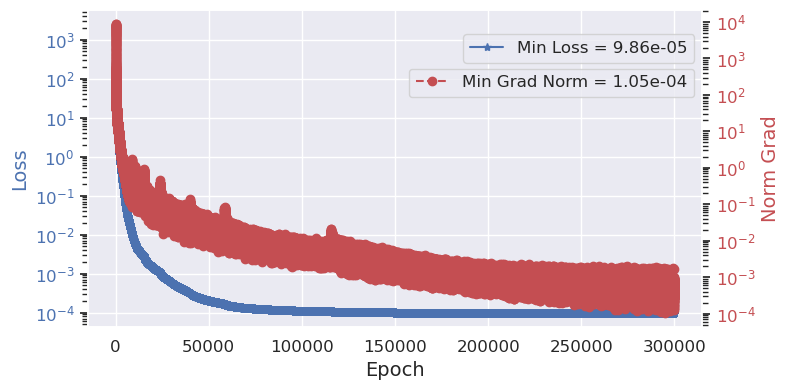

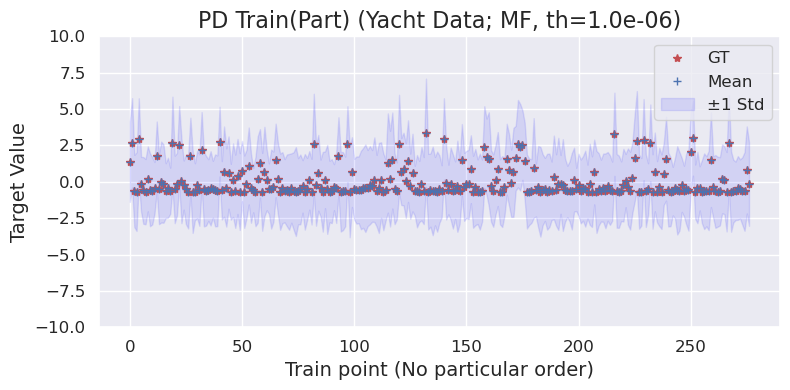

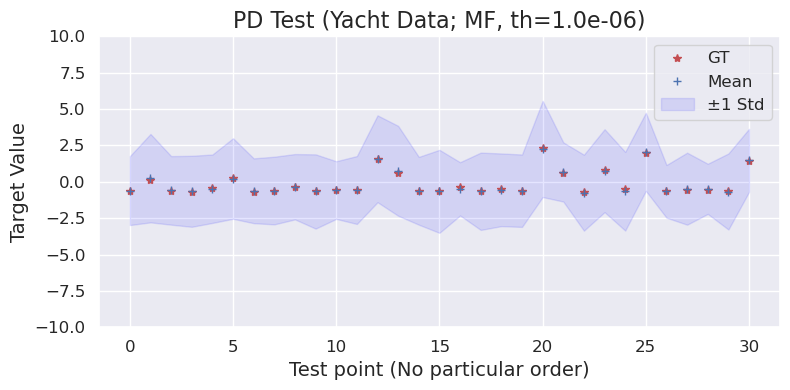

In [21]:
DATA_NAME = 'yacht' # yacht, energy, concrete, wine_red
TEST_SIZE, SPLIT_SEED = 0.1, 1
TRANSFORM_X, TRANSFORM_Y, SCALER = True, True, 'std'
# Prepare the data:
x, x_test, y, y_test = load_transform_data(DATA_DIR / f'{DATA_NAME}.csv', TEST_SIZE, SPLIT_SEED, TRANSFORM_X, TRANSFORM_Y, SCALER)
x, x_test, y, y_test = map(jnp.array, [x, x_test, y, y_test])
dt = [x, x_test, y, y_test]
n_samples, d_dim = x.shape
print(f"(N, D) ={ x.shape}")
conf = dict(
    gamma_w=1e-6, beta_e=1.0,
    hidden_dim=80, lr=1e-3, opt_method='adam', n_epoch=300000, use_linesearch=True,
    seed=13, hess_type='mf', low_rank=True, low_rank_th=1e-6,
)
nn_w_trained, w_hess, w_cov, w_cholesky, tracker = train_model_nn(x, y, conf)
stats = compute_stats_nn(dt, conf, nn_w_trained, w_hess, w_cholesky, tracker)
print(f"P={n_params(nn_w_trained)}")
display(stats)

plot_dual_axis( 
    tracker['loss'], 
    tracker['grad_norm'],
    x=None,
    leg_y1=f'Min Loss = {min(tracker["loss"]):.2e}',
    leg_y2=f'Min Grad Norm = {min(tracker["grad_norm"]):.2e}',
    xlabel='Epoch',
    y1_label='Loss',
    y2_label='Norm Grad',
    x_scale='linear',
    y1_scale='log',
    y2_scale='log',
    title='',
    save_path=None,
    dpi=200,
)

plot_prediction(
    y, 
    forward_nn(nn_w_trained, x), 
    predict_std_nn(nn_w_trained, w_cholesky, x, conf['beta_e'], n_samples=50), 
    xlabel='Train point (No particular order)',
    ylabel='Target Value',
    title=f'PD Train(Part) ({DATA_NAME.capitalize()} Data; {conf["hess_type"].upper()}, th={conf["low_rank_th"]:.1e})',
    save_path=None,
    ylim=(-10, 10)
)

plot_prediction(
    y_test, 
    forward_nn(nn_w_trained, x_test), 
    predict_std_nn(nn_w_trained, w_cholesky, x_test, conf['beta_e'], n_samples=50), 
    xlabel='Test point (No particular order)',
    ylabel='Target Value',
    title=f'PD Test ({DATA_NAME.capitalize()} Data; {conf["hess_type"].upper()}, th={conf["low_rank_th"]:.1e})',
    save_path=None,
    ylim=(-10, 10)
)

##### Train NN:

In [9]:
DATA_NAME = 'energy' # yacht, energy, concrete, wine_red
TEST_SIZE, SPLIT_SEED = 0.1, 1
TRANSFORM_X, TRANSFORM_Y, SCALER = True, True, 'std'
TRAIN = False

# Prepare the data:
x, x_test, y, y_test = load_transform_data(
    DATA_DIR / f'{DATA_NAME}.csv', TEST_SIZE, SPLIT_SEED, TRANSFORM_X, TRANSFORM_Y, SCALER)
x, x_test, y, y_test = map(jnp.array, [x, x_test, y, y_test])
dt = [x, x_test, y, y_test]
n_samples, d_dim = x.shape

RES_DIR = Path(f'./artifacts/cov_comparison/neural_net/{DATA_NAME}/training_artifacts/')
create_dir_if_not_exists(RES_DIR)

params = dict(gamma_w=[1e-6,], beta_e=[1.0,], seed=[13,], 
    hidden_dim=[80,], lr=[1e-3,], opt_method=['adam',], n_epoch=[300000,], use_linesearch=[True,],
    hess_type=['mf', 'block', 'full'], low_rank=[True,], 
    low_rank_th=[1e-6, 1e-5, 1e-3, 1e-2, 1e-1, 1e0, 1e1, 1e2],
)
conf_map = {k:v[0] for k, v in params.items() if k in ['gamma_w', 'beta_e', 'seed', 'hidden_dim', 'lr', 'opt_method', 'n_epoch', 'use_linesearch']}
grid, param_names = full_grid(params)
if TRAIN:
    # Find MAP:
    conf_map = {k:v[0] for k, v in params.items() if k in ['gamma_w', 'beta_e', 'seed', 'hidden_dim', 'lr', 'opt_method', 'n_epoch', 'use_linesearch']}
    nn_w = init_params(random.PRNGKey(conf_map['seed']), input_dim=x.shape[1], hidden_dim=conf_map['hidden_dim'], output_dim=1)
    nn_w_trained, tracker = train_map_nn(nn_w, x, y, conf_map['beta_e'], conf_map['gamma_w'], 
        conf_map['use_linesearch'], conf_map['opt_method'], conf_map['lr'], conf_map['n_epoch']
    )
    save_dict_np(nn_w_trained, RES_DIR / 'map_weights.npz')
    save_dict_np(tracker, RES_DIR / 'map_tracker.npz')
    # Check Hesian:
    res_dict = defaultdict(list)
    for v in tqdm(grid):
        conf = dict(zip(param_names, v))
        w_hess, w_cov, w_cholesky = hess_cov_estimation_nn(
            nn_w_trained, x, y, conf_map['gamma_w'], 
            conf_map['beta_e'], conf['hess_type'], conf['low_rank'], conf['low_rank_th']
        )
        stats = compute_stats_nn(dt, conf, nn_w_trained, w_hess, w_cholesky, tracker)
        update_results_dict(res_dict, **stats, **conf)
    res_df = pd.DataFrame(res_dict)
    res_df.to_csv(RES_DIR / 'nll_info.csv')
else:
    res_df = pd.read_csv(RES_DIR / 'nll_info.csv', index_col=0)
    nn_w_trained = load_dict_jax(RES_DIR / 'map_weights.npz')
    tracker = load_dict_jax(RES_DIR / 'map_tracker.npz')

SAVE_DIR = Path(f'./artifacts/cov_comparison/neural_net/{DATA_NAME}/results/')
create_dir_if_not_exists(SAVE_DIR)

PosixPath('artifacts/cov_comparison/neural_net/energy/results')

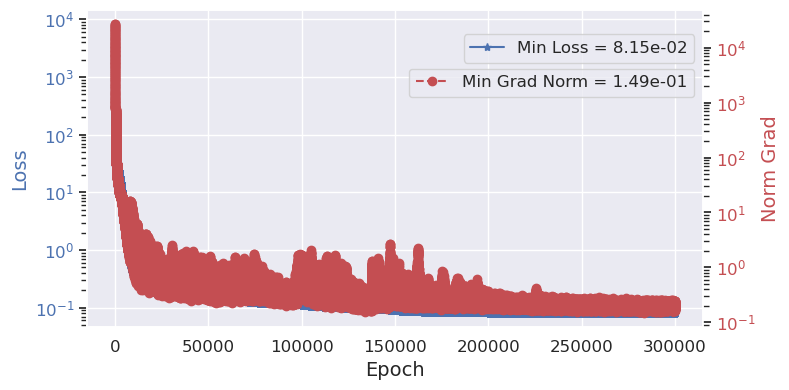

In [5]:
plot_dual_axis( 
    tracker['loss'], 
    tracker['grad_norm'],
    x=None,
    leg_y1=f'Min Loss = {min(tracker["loss"]):.2e}',
    leg_y2=f'Min Grad Norm = {min(tracker["grad_norm"]):.2e}',
    xlabel='Epoch',
    y1_label='Loss',
    y2_label='Norm Grad',
    x_scale='linear',
    y1_scale='log',
    y2_scale='log',
    title='',
    save_path=None,
    dpi=200,
)

##### Hessian Estimators:

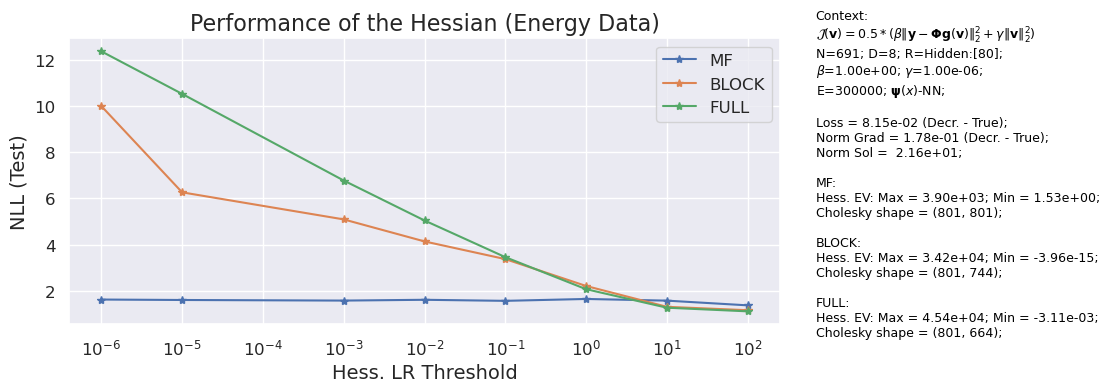

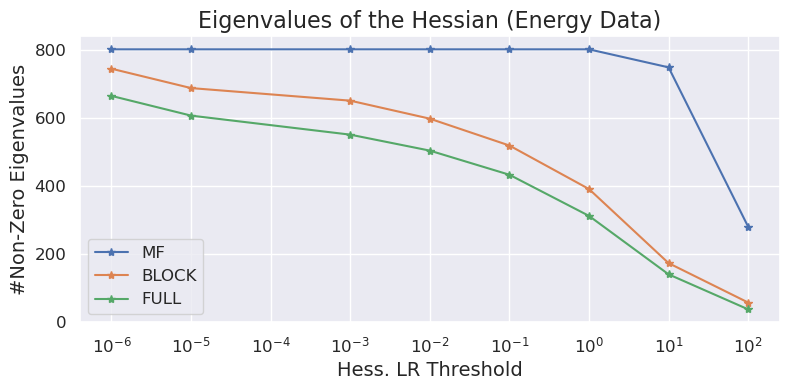

In [7]:
x_name, y_name = 'low_rank_th', 'nll_test'
y_list, leg_list, text_list = [], [], []
for hess_type in params['hess_type']:
    tdf = query_df(res_df, dict(hess_type=hess_type)).sort_values(by=x_name)
    y_list.append(tdf[y_name])
    leg_list.append(hess_type.upper())
    x_range = tdf[x_name]
    text_list.append(
        (
            f'\n{hess_type.upper()}:\n'
            + f'Hess. EV: Max = {tdf["max_ev"].iloc[0]:.2e}; Min = {tdf["min_ev"].iloc[0]:.2e};\n'
            + f'Cholesky shape = {tdf["w_chol_shape"].iloc[0]};\n'
        )
    )
remove_cols = ['hess_type', 'low_rank', 'low_rank_th', 'hidden_dim', 'lr', 'opt_method', 'use_linesearch']
p_fixed = {k:v[0] for k, v in params.items() if k not in remove_cols}
p_fixed['fmap'] = 'NN'
p_fixed['rank'] = f"Hidden:{params['hidden_dim']}"
p_fixed['m_order'] = None

loss_val, loss_dec = res_df['loss'][0], res_df['loss_down'][0]
gd_norm_val, gd_norm_dec = res_df['gd_norm'][0], res_df['gd_down'][0]
w_norm = res_df['w_norm'][0]

text = get_text(n_samples, d_dim, **p_fixed)
text += (
    f'\nLoss = {loss_val:.2e} (Decr. - {loss_dec});\n'
    + f'Norm Grad = {gd_norm_val:.2e} (Decr. - {gd_norm_dec});\n'
    + f'Norm Sol = {w_norm: .2e};\n'
)
for v in text_list:
    text += v

plot_y_list(
    y_list, x_range, leg_list, 
    xlabel='Hess. LR Threshold', 
    ylabel='NLL (Test)', 
    x_scale='log', 
    text=text,
    title=f'Performance of the Hessian ({DATA_NAME.capitalize()} Data)',
    save_path=SAVE_DIR / f'{DATA_NAME}_hess_perf.png'
)

x_name, y_name = 'low_rank_th', 'w_chol_shape'
y_list, leg_list, text_list = [], [], []
for hess_type in params['hess_type']:
    tdf = query_df(res_df, dict(hess_type=hess_type)).sort_values(by=x_name)
    y_list.append([int(v.strip('()').split(',')[1]) for v in tdf[y_name]])
    leg_list.append(hess_type.upper())
    x_range = tdf[x_name]

plot_y_list(
    y_list, x_range, leg_list, 
    xlabel='Hess. LR Threshold', 
    ylabel='#Non-Zero Eigenvalues', 
    x_scale='log',
    title=f'Eigenvalues of the Hessian ({DATA_NAME.capitalize()} Data)',
    save_path=SAVE_DIR / f'{DATA_NAME}_nonzero_ev.png'
)

##### Predictive Distribution:

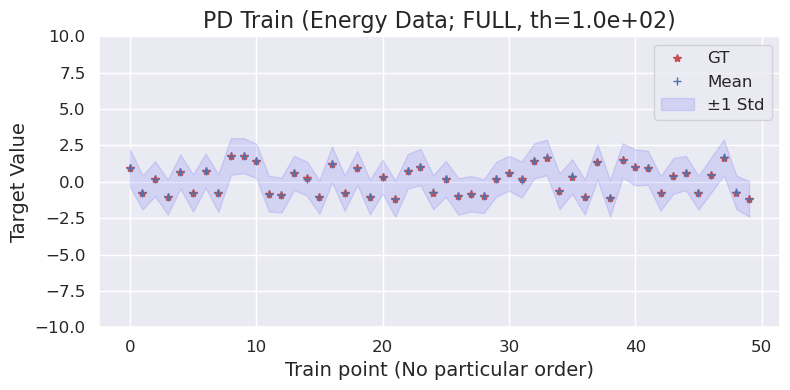

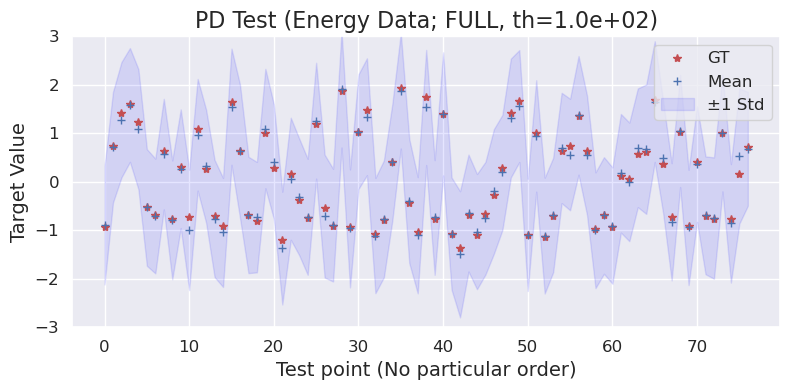

In [10]:
hess_type = 'full'

changed_cols = ['hess_type', 'low_rank', 'low_rank_th']
p_fixed = {k:v[0] for k, v in params.items() if k not in changed_cols}
best_setting = dict(query_df(res_df, dict(hess_type=hess_type)).sort_values(by='nll_test', ascending=True).iloc[0])
conf = p_fixed | {k:v for k, v in best_setting.items() if k in changed_cols}

w_hess, w_cov, w_cholesky = hess_cov_estimation_nn(
    nn_w_trained, x, y, conf_map['gamma_w'], 
    conf_map['beta_e'], conf['hess_type'], conf['low_rank'], conf['low_rank_th']
)

n_train_show = 50
plot_prediction(
    y[:n_train_show], 
    forward_nn(nn_w_trained, x[:n_train_show, :]), 
    predict_std_nn(nn_w_trained, w_cholesky, x[:n_train_show, :], conf['beta_e'], n_samples=50), 
    xlabel='Train point (No particular order)',
    ylabel='Target Value',
    title=f'PD Train ({DATA_NAME.capitalize()} Data; {conf["hess_type"].upper()}, th={conf["low_rank_th"]:.1e})',
    save_path=SAVE_DIR / f'{DATA_NAME}_pred_dist_train.png',
    ylim=(-10, 10)
)

plot_prediction(
    y_test, 
    forward_nn(nn_w_trained, x_test), 
    predict_std_nn(nn_w_trained, w_cholesky, x_test, conf['beta_e'], n_samples=50), 
    xlabel='Test point (No particular order)',
    ylabel='Target Value',
    title=f'PD Test ({DATA_NAME.capitalize()} Data; {hess_type.upper()}, th={conf["low_rank_th"]:.1e})',
    save_path=SAVE_DIR / f'{DATA_NAME}_pred_dist_test.png',
    ylim=(-3, 3)
)

##### PD Gif:

In [43]:
means_list = []
stds_list = []
for th in tqdm(params['low_rank_th']):
    conf = p_fixed | dict(hess_type=hess_type, low_rank=True, low_rank_th=th)
    w_hess, w_cov, w_cholesky = hess_cov_estimation_nn(
        nn_w_trained, x, y, conf_map['gamma_w'], 
        conf_map['beta_e'], conf['hess_type'], conf['low_rank'], conf['low_rank_th']
    )
    means_list.append(forward_nn(nn_w_trained, x_test))
    stds_list.append(predict_std_nn(nn_w_trained, w_cholesky, x_test, conf['beta_e'], n_samples=50))

generate_prediction_gif(
    x_vals=params['low_rank_th'],
    y_gt=y_test,
    means_list=means_list,
    stds_list=stds_list,
    save_gif_path=SAVE_DIR / f'{DATA_NAME}_pred_dist.gif',
    xlabel=f'Test point ({DATA_NAME.capitalize()} Data)',
    ylabel='Target value',
    title_prefix=f'Predictive Distribution. {hess_type.upper()}, ',
    duration=1000,  # seconds per frame
    ylim=(-6, 6) 
)

100%|██████████| 8/8 [00:17<00:00,  2.19s/it]


##### Covariance matrix eigenvalues:

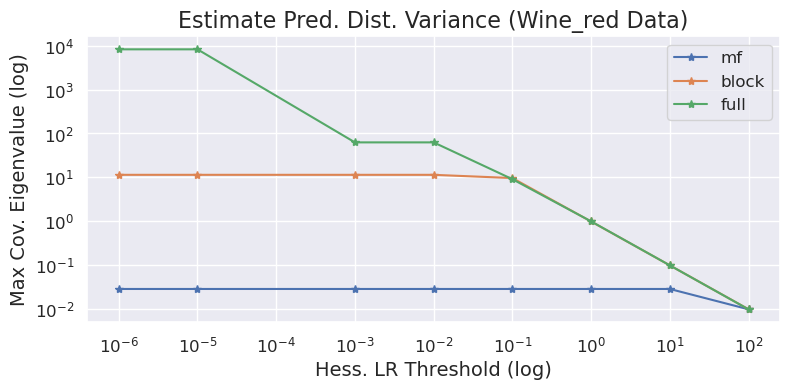

In [44]:
hess_dict, y_list = {}, []
for hess_type in params['hess_type']:
    conf = p_fixed | dict(hess_type=hess_type, low_rank=True, low_rank_th=1e-1)
    w_hess, _, _ = hess_cov_estimation_nn(
        nn_w_trained, x, y, conf_map['gamma_w'], 
        conf_map['beta_e'], conf['hess_type'], conf['low_rank'], conf['low_rank_th']
    )
    hess_dict[hess_type] = np.array(w_hess)
    ys = []
    for th in params['low_rank_th']:
        s, u = np.linalg.eigh(w_hess)
        mask = s >= th
        ys.append(1/min(s[mask]))
    y_list.append(ys)

plot_y_list(
    y_list, 
    x=params['low_rank_th'], 
    leg_list=params['hess_type'], 
    xlabel='Hess. LR Threshold (log)', 
    ylabel='Max Cov. Eigenvalue (log)',
    x_scale='log',
    y_scale='log',
    title=f'Estimate Pred. Dist. Variance ({DATA_NAME.capitalize()} Data)',
    save_path=SAVE_DIR / f'{DATA_NAME}_cov_max_ev_th.png'
)

#### GP Baseline:

RMSE Train: 0.6647234729150049; RMSE Test: 0.6706412903812703; NLL Test: 1.27119283722552


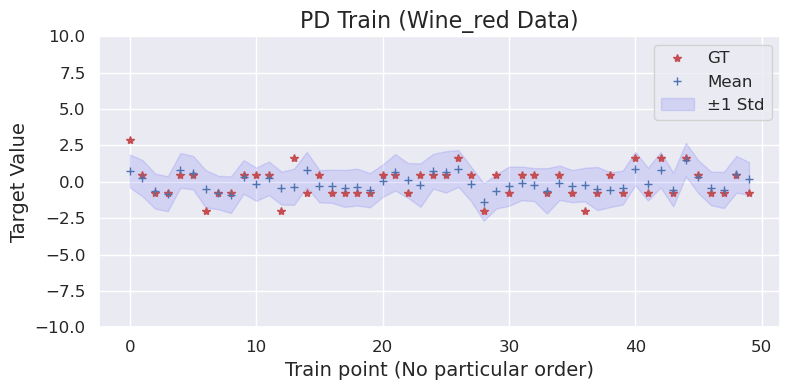

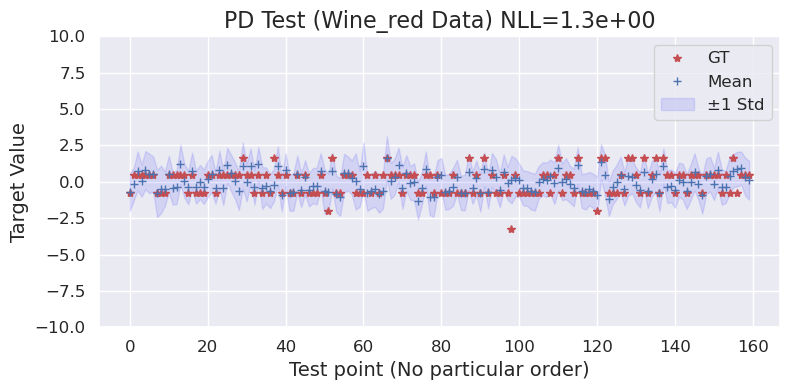

In [102]:
from sklearn.gaussian_process import GaussianProcessRegressor
import sklearn.gaussian_process.kernels as gp_kern

DATA_NAME = 'wine_red' # yacht, energy, concrete, wine_red
TEST_SIZE, SPLIT_SEED = 0.1, 1
TRANSFORM_X, TRANSFORM_Y, SCALER = True, True, 'std'
TRAIN = True

# Prepare the data:
x, x_test, y, y_test = load_transform_data(
    DATA_DIR / f'{DATA_NAME}.csv', TEST_SIZE, SPLIT_SEED, TRANSFORM_X, TRANSFORM_Y, SCALER)
x, x_test, y, y_test = map(jnp.array, [x, x_test, y, y_test])
dt = [x, x_test, y, y_test]
n_samples, d_dim = x.shape

#RES_DIR = Path(f'./artifacts/cov_comparison/gaussian_process/{DATA_NAME}/training_artifacts/')
#create_dir_if_not_exists(RES_DIR)

kernel = (
    gp_kern.RBF(length_scale=1, length_scale_bounds=(1e-3, 1e3)) 
    #+ gp_kern.WhiteKernel(noise_level=1, noise_level_bounds=(1e-10, 1e3))
)

model = GaussianProcessRegressor(
    kernel=kernel, 
    alpha=0.5,
    random_state=0,
    n_restarts_optimizer=15,
)
model.fit(x, y)

pred_mean_train, pred_std_train = model.predict(x, return_std=True)
pred_std_train += 1.0
pred_mean_test, pred_std_test = model.predict(x_test, return_std=True)
pred_std_test += 1.0
nll_test = nll(pred_mean_test, pred_std_test**2, y_test)
print(f"RMSE Train: {rmse(y, pred_mean_train)}; RMSE Test: {rmse(y_test, pred_mean_test)}; NLL Test: {nll_test}")

SAVE_DIR = Path(f'./artifacts/cov_comparison/gaussian_process/{DATA_NAME}/results/')
create_dir_if_not_exists(SAVE_DIR)

n_train_show = 50
plot_prediction(
    y[:n_train_show], pred_mean_train[:n_train_show], pred_std_train[:n_train_show],
    xlabel='Train point (No particular order)',
    ylabel='Target Value',
    title=f'PD Train ({DATA_NAME.capitalize()} Data)',
    save_path=SAVE_DIR / f'{DATA_NAME}_pred_dist_train.png',
    ylim=(-10, 10)
)

plot_prediction(
    y_test, pred_mean_test, pred_std_test,
    xlabel='Test point (No particular order)',
    ylabel='Target Value',
    title=f'PD Test ({DATA_NAME.capitalize()} Data) NLL={nll_test:.1e}',
    save_path=SAVE_DIR / f'{DATA_NAME}_pred_dist_test.png',
    ylim=(-10, 10)
)